**Downloading Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/video_data" "/content/videos" # copy dataset from drive

**Converting videos to 1FPS**

In [ ]:
import os
import subprocess
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

video_directory = "/content/videos/video"
output_directory = "/content/1FPS_videos"
target_fps = 1
max_workers = 4 # 4 or 8 for local disk

os.makedirs(output_directory, exist_ok=True)

def process_video_gpu(video_file):
    input_path = os.path.join(video_directory, video_file)
    output_path = os.path.join(output_directory, video_file)


    if os.path.exists(output_path):
        return

    command = [
        'ffmpeg', '-y', '-hwaccel', 'auto', '-i', input_path,
        '-r', str(target_fps),
        '-c:v', 'h264_nvenc', '-preset', 'p1',
        '-c:a', 'copy',
        output_path,
        '-loglevel', 'error'
    ]

    try:
        subprocess.run(command, check=True)
    except Exception as e:
        pass

video_files = [f for f in os.listdir(video_directory) if f.lower().endswith(('.mp4', '.avi', '.mov'))]

print(f"🚀 Processing {len(video_files)} videos from LOCAL SSD...")

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    list(tqdm(executor.map(process_video_gpu, video_files), total=len(video_files)))

🚀 Processing 8588 videos from LOCAL SSD...


 44%|████▍     | 3815/8588 [34:00<23:43,  3.35it/s]

In [ ]:
import os

path = "/content/drive/MyDrive/1FPS_video"

count = len([f for f in os.listdir(path) if f.endswith('.mp4')])

print(f"Congratulations! Total {count} videos found.")

Congratulations! Total 8588 videos found.


In [ ]:
!pip install mtcnn facenet-pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 841.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121

**Video Face Embeddings Extraction**

In [ ]:
import cv2
import os
import pandas as pd
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
video_directory = "/content/drive/MyDrive/1FPS_video"
output_file = "/content/drive/MyDrive/Embedding /videos_face_embeddings.csv"
SAVE_INTERVAL = 10  # Save every 10 videos for safety
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- INITIALIZE MODELS ---
detector = MTCNN(keep_all=True, device=device, post_process=True)
facenet_model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# --- RESUME LOGIC: Check what is already done ---
processed_videos = set()
if os.path.exists(output_file):
    try:
        # We only read the 'Link' column to save RAM
        existing_df = pd.read_csv(output_file, usecols=['Link'])
        # Get unique basenames to match against our folder
        processed_videos = set(existing_df['Link'].apply(os.path.basename).unique())
        print(f"Resuming: {len(processed_videos)} videos already processed. Skipping them...")
    except Exception as e:
        print(f"Could not read existing CSV (maybe empty?): {e}")

# Filter out videos already in the CSV
all_video_files = [f for f in os.listdir(video_directory) if f.endswith(".mp4")]
video_files = [f for f in all_video_files if f not in processed_videos]

print(f"Remaining videos to process: {len(video_files)}")

all_features = []

# --- EXTRACTION LOOP ---
for idx, video_file in enumerate(tqdm(video_files, desc="Processing Videos")):
    v_path = os.path.join(video_directory, video_file)
    cap = cv2.VideoCapture(v_path)

    video_label = video_file[0] # Taking first char as label
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        with torch.no_grad():
            faces = detector(frame_rgb)

            if faces is not None:
                faces = faces.to(device)
                embeddings = facenet_model(faces).cpu().numpy()

                for emb in embeddings:
                    # Storing the full path to stay consistent with your data
                    all_features.append([v_path, frame_idx, video_label] + emb.tolist())

        frame_idx += 1

    cap.release()

    # --- PERIODIC SAVE ---
    if (idx + 1) % SAVE_INTERVAL == 0 and all_features:
        df_chunk = pd.DataFrame(all_features)

        # Check if we need to write the header
        file_exists = os.path.isfile(output_file)

        # Set Column Names
        num_emb = len(all_features[0]) - 3
        cols = ["Link", "Frame", "Label"] + [f"E_{i}" for i in range(num_emb)]
        df_chunk.columns = cols

        # Append to CSV
        df_chunk.to_csv(output_file, mode='a', index=False, header=not file_exists)

        all_features = [] # Clear RAM
        # Optional: Sync to Google Drive immediately
        # from google.colab import drive
        # drive.flush_and_unmount() # Only if you want to be extremely paranoid

# --- FINAL SAVE ---
if all_features:
    df_final = pd.DataFrame(all_features)
    file_exists = os.path.isfile(output_file)
    num_emb = len(all_features[0]) - 3
    df_final.columns = ["Link", "Frame", "Label"] + [f"E_{i}" for i in range(num_emb)]
    df_final.to_csv(output_file, mode='a', index=False, header=not file_exists)

print(f"\nFinished! Processed videos added to {output_file}")

  0%|          | 0.00/107M [00:00<?, ?B/s]

Resuming: 7788 videos already processed. Skipping them...
Remaining videos to process: 800


Processing Videos: 100%|██████████| 800/800 [1:26:43<00:00,  6.50s/it]


Finished! Processed videos added to /content/drive/MyDrive/Embedding /videos_face_embeddings.csv


**Neural Network for Facial Emotion Recognition**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
import os

# --- 1. Load Data ---
features_df = pd.read_csv("/content/drive/MyDrive/Embedding /videos_face_embeddings.csv")

# --- 2. THE CLEANING (Fixed & Combined) ---
def fix_labels(link):
    text = str(link).lower() # Normalizes case (Sad vs sad)

    # Priority mapping for typos and merged classes
    if 'anger' in text: return 'Anger'
    if 'sad' in text: return 'Sad'
    if 'love' in text: return 'Love'
    if 'happy' in text: return 'Happy'
    if 'netural' in text or 'neutral' in text: return 'Neutral'

    return 'Other'

# Apply the clean labels
features_df['Clean_Label'] = features_df['Link'].apply(fix_labels)

# Drop 'Other' and the original messy 'Label' column
features_df = features_df[features_df['Clean_Label'] != 'Other']

# --- 3. Grouping and Mean ---
# We use 'Clean_Label' here to ensure the typos are merged
X_grouped = features_df.drop(columns=["Frame", "Label"]).groupby(['Link', 'Clean_Label']).mean(numeric_only=True).reset_index()

# Prepare data for Training
X_VF_np = X_grouped.drop(columns=['Link', 'Clean_Label']).values
Y_labels = X_grouped['Clean_Label'].values

# --- 4. Encoding ---
encoder = LabelEncoder()
Y_VF_encoded = encoder.fit_transform(Y_labels)

# Convert to Tensors
X_VF = torch.tensor(X_VF_np, dtype=torch.float32)
Y_VF = torch.tensor(Y_VF_encoded, dtype=torch.long)

# --- 5. Shuffling and Splitting (Using Stratify for better results) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_VF, Y_VF, test_size=0.2, random_state=42, shuffle=True, stratify=Y_VF
)

# --- 6. GPU Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# --- NeuralNet Class ---
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

input_size = X_train.shape[1]
num_classes = len(encoder.classes_)
model = NeuralNet(input_size, num_classes).to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Training ---
# Initialize lists to store progress
train_losses = []
train_accs = []

# Training the model
num_epochs = 400
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass and optimize
    loss.backward()
    optimizer.step()

    # Track Loss
    train_losses.append(loss.item())

    # Track Accuracy during training
    _, predicted_train = torch.max(outputs, 1)
    acc = (predicted_train == y_train).sum().item() / y_train.size(0)
    train_accs.append(acc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Acc: {acc*100:.2f}%')

# --- Evaluation ---
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    accuracy = correct / total * 100
    print(f"\nFinal Test accuracy: {accuracy:.2f}%")
    print("Classes Trained On:", encoder.classes_)

Epoch [20/400], Loss: 1.2808, Acc: 48.19%
Epoch [40/400], Loss: 1.0735, Acc: 57.93%
Epoch [60/400], Loss: 0.8783, Acc: 66.43%
Epoch [80/400], Loss: 0.7189, Acc: 73.54%
Epoch [100/400], Loss: 0.6250, Acc: 76.59%
Epoch [120/400], Loss: 0.5064, Acc: 81.97%
Epoch [140/400], Loss: 0.4470, Acc: 84.34%
Epoch [160/400], Loss: 0.3923, Acc: 86.25%
Epoch [180/400], Loss: 0.3076, Acc: 90.86%
Epoch [200/400], Loss: 0.2578, Acc: 92.84%
Epoch [220/400], Loss: 0.2847, Acc: 90.06%
Epoch [240/400], Loss: 0.1917, Acc: 95.50%
Epoch [260/400], Loss: 0.1537, Acc: 97.13%
Epoch [280/400], Loss: 0.1289, Acc: 98.06%
Epoch [300/400], Loss: 0.1122, Acc: 98.43%
Epoch [320/400], Loss: 0.0899, Acc: 99.10%
Epoch [340/400], Loss: 0.0740, Acc: 99.42%
Epoch [360/400], Loss: 0.0596, Acc: 99.74%
Epoch [380/400], Loss: 0.0489, Acc: 99.85%
Epoch [400/400], Loss: 0.0405, Acc: 99.93%

Final Test accuracy: 53.29%
Classes Trained On: ['Anger' 'Happy' 'Love' 'Neutral' 'Sad']


**Confusion Matrix**

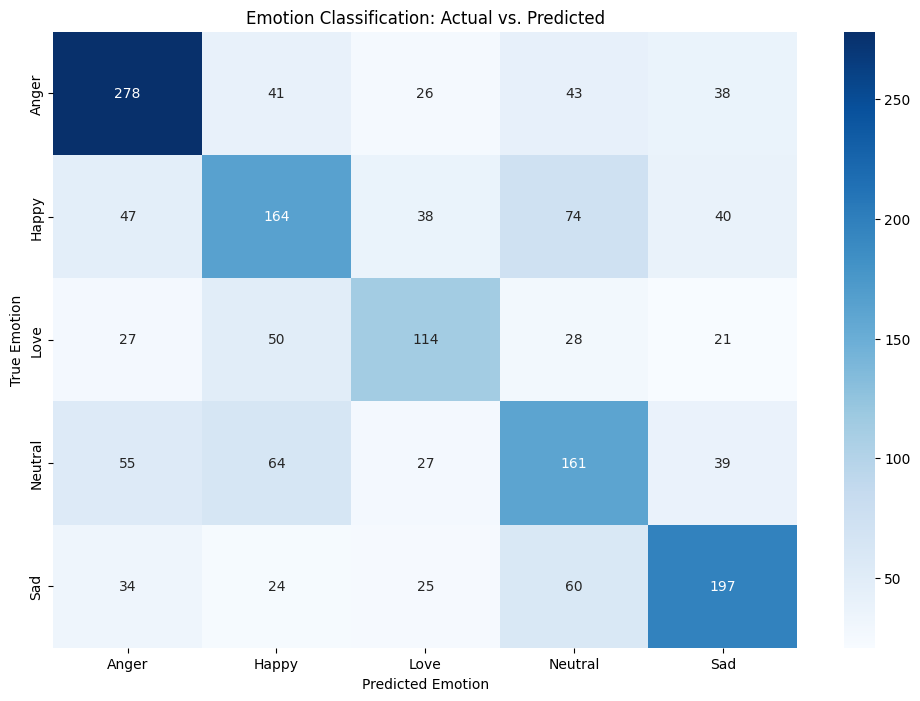


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       Anger       0.63      0.65      0.64       426
       Happy       0.48      0.45      0.46       363
        Love       0.50      0.47      0.49       240
     Neutral       0.44      0.47      0.45       346
         Sad       0.59      0.58      0.58       340

    accuracy                           0.53      1715
   macro avg       0.53      0.52      0.53      1715
weighted avg       0.53      0.53      0.53      1715



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert tensors back to CPU and then to numpy for Scikit-Learn
y_true = y_test.cpu().numpy()
y_pred = predicted.cpu().numpy()

# 2. Get the actual emotion names from your encoder
emotion_names = encoder.classes_

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plotting using Seaborn for a professional look
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names
)

plt.title('Emotion Classification: Actual vs. Predicted')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()

# 5. Print a text-based report for precision/recall details
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=emotion_names))